# Notebook 5 — A **reverse (inverse) PINN** for the drag problem
### Discovering the hidden drag coefficient k from noisy data · research log

**The goal that makes this notebook feel like real research.** Suppose I film a projectile
flying through the air and extract a handful of noisy $(x,y)$ positions over time. I know it
was thrown, and roughly how — but I do **not** know the object's **drag coefficient $k$**, a
property of its shape and the air. Can a PINN look at those noisy points and *tell me $k$*?

This is the classic inverse problem PINNs were popularised for: **discovering an unknown
coefficient of a differential equation from data**. In Notebook 4 I recovered launch
conditions for the simple parabola; here I recover a coefficient buried inside a **nonlinear**
equation of motion that has no closed-form solution — which is where this technique really
earns its keep, because there's no formula to invert by hand.

**My setup.** The drag equations of motion from Notebook 3 are
$$ \ddot x = -k\,v\,\dot x,\qquad \ddot y = -g-k\,v\,\dot y,\qquad v=\sqrt{\dot x^2+\dot y^2}. $$
I assume I know how the object was launched (its initial velocity) but **not** $k$. I make
$k$ a **trainable parameter**, train a time-domain network $(t)\mapsto(x,y)$ to fit the noisy
data while obeying these equations, and read off the $k$ that gradient descent settles on.

**A detail I'm careful about:** $k$ must stay non-negative (negative drag is unphysical), so I
don't optimise $k$ directly — I optimise an unconstrained number and pass it through a
`softplus` so the result is always $\ge 0$. Small thing, but it stops the optimiser wandering
into nonsense.

## Setup
PyTorch for the network/autograd, NumPy for the RK4 simulator I use to *manufacture* the noisy
data, Matplotlib for plots.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
torch.manual_seed(0)
np.random.seed(0)
g = 9.81

Device: cpu


## Manufacturing the noisy observations with RK4
As in Notebook 3, I have no formula for a drag trajectory, so I generate my "experimental"
data by integrating the true equations with **RK4** at a hidden value of $k$, then sampling a
few points and adding noise. This is purely to create a test where I *know* the right answer.
The same RK4 integrator (validated back in Notebook 3) appears here.

- **Hidden truth:** $u=30$ m/s, $\theta=45°$, $k_{\text{true}}=0.012$ /m.
- I sample **20** points along the flight and add Gaussian noise (std $0.4$ m) to both $x$ and
  $y$, mimicking imperfect position measurements.

In [2]:
def deriv(s, k):
    x, y, vx, vy = s; v = np.sqrt(vx*vx + vy*vy)
    return np.array([vx, vy, -k*v*vx, -g - k*v*vy])
def rk4_step(s, dt, k):
    a=deriv(s,k); b=deriv(s+dt/2*a,k); c=deriv(s+dt/2*b,k); d=deriv(s+dt*c,k)
    return s + dt/6*(a + 2*b + 2*c + d)
def integrate(u, th_deg, k, dt=0.002):
    r=np.radians(th_deg); s=np.array([0.,0.,u*np.cos(r),u*np.sin(r)]); T=[0.];X=[0.];Y=[0.]; t=0.
    while t < 20:
        sn = rk4_step(s, dt, k)
        if sn[1] < 0 and s[1] >= 0:
            f=s[1]/(s[1]-sn[1]); t+=f*dt; T.append(t); X.append((s+f*(sn-s))[0]); Y.append(0.); break
        s=sn; t+=dt; T.append(t); X.append(s[0]); Y.append(s[1])
    return np.array(T), np.array(X), np.array(Y)

u0, th0, k_true = 30.0, 45.0, 0.012        # hidden truth (k_true is what I must discover)
r = np.radians(th0); vx0, vy0 = u0*np.cos(r), u0*np.sin(r)
T, X, Y = integrate(u0, th0, k_true)       # full RK4 trajectory

N = 20
idx = np.linspace(0, len(T)-1, N).astype(int)
t_obs = T[idx]
x_obs = X[idx] + np.random.normal(0, 0.4, N)
y_obs = Y[idx] + np.random.normal(0, 0.4, N)

T_ref = float(T[-1]); x_scale = float(X.max()); y_scale = float(Y.max())
print(f"Hidden k = {k_true}.  Flight {T_ref:.2f}s, range {X[-1]:.1f}m.  Measured {N} noisy points.")

Hidden k = 0.012.  Flight 3.64s, range 52.1m.  Measured 20 noisy points.


## The data I'm given
My noisy measured points, with the (hidden) true RK4 trajectory faint behind them. Note the
asymmetry — steeper on the way down — which is the fingerprint of drag and the thing that
encodes $k$ in the data.

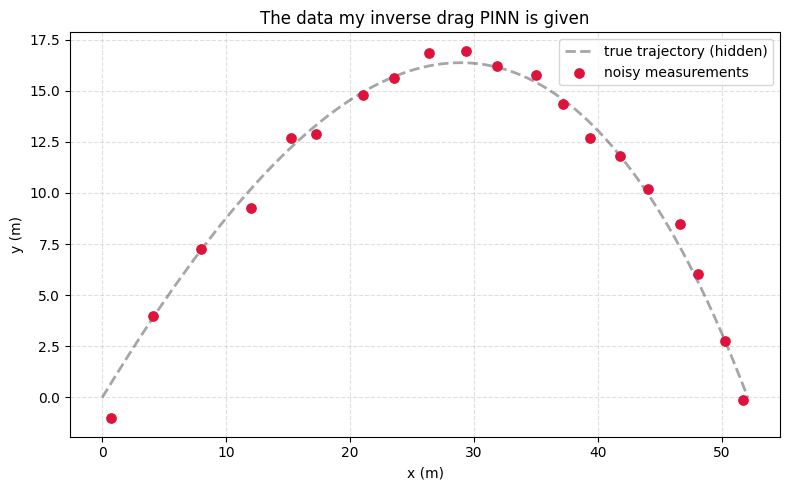

In [3]:
plt.figure(figsize=(8,5))
plt.plot(X, Y, 'k--', alpha=0.35, lw=2, label='true trajectory (hidden)')
plt.scatter(x_obs, y_obs, color='crimson', s=45, zorder=5, label='noisy measurements')
plt.xlabel('x (m)'); plt.ylabel('y (m)'); plt.title('The data my inverse drag PINN is given')
plt.legend(); plt.grid(True, ls='--', alpha=0.4); plt.tight_layout(); plt.show()

## Network + the trainable drag coefficient
The network maps **time** to **position**, $(t)\mapsto(x_{\text{norm}},y_{\text{norm}})$, just
like the forward drag PINN — and outputs normalised positions (a `Tanh` net needs that to reach
realistic magnitudes). The new ingredient is the single unknown I'm chasing:
`k_raw`, an unconstrained parameter, mapped through `softplus` and scaled into a sensible range
so the **effective $k$ is always $\ge 0$**. It starts well away from the truth so the recovery
is a fair test.

In [4]:
to = torch.tensor(t_obs, dtype=torch.float32, device=device).unsqueeze(1)
xo = torch.tensor(x_obs, dtype=torch.float32, device=device).unsqueeze(1) / x_scale   # normalised
yo = torch.tensor(y_obs, dtype=torch.float32, device=device).unsqueeze(1) / y_scale

class FCN(nn.Module):
    def __init__(self, N_HIDDEN=48, N_LAYERS=4):
        super().__init__()
        act = nn.Tanh
        layers = [nn.Linear(1, N_HIDDEN), act()]
        for _ in range(N_LAYERS-1):
            layers += [nn.Linear(N_HIDDEN, N_HIDDEN), act()]
        layers += [nn.Linear(N_HIDDEN, 2)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t / T_ref)            # -> [x_norm, y_norm]

net = FCN().to(device)

# The unknown to DISCOVER. softplus keeps k >= 0; the 0.05 scales it into a realistic band.
k_raw = torch.nn.Parameter(torch.tensor(-2.0, device=device))   # start far from the truth
def k_value():
    return F.softplus(k_raw) * 0.05

def d(out, t):
    return torch.autograd.grad(out, t, torch.ones_like(out), create_graph=True)[0]
print(f"Initial k estimate: {k_value().item():.5f}  (hidden truth {k_true})")

Initial k estimate: 0.00635  (hidden truth 0.012)


## The loss: match the data, obey the drag equations, respect the known launch
Three terms again, all normalised to order 1:
- **Data loss** — the network must pass near the measured $(x,y)$ points (the information source).
- **Physics loss** — the network's own accelerations must satisfy the **drag equations with the
  trainable $k$**: residuals $R_x=\ddot x+k v\dot x$ and $R_y=\ddot y+k v\dot y+g$, normalised by
  $g$. This is the term that *connects the data to $k$*: the only $k$ that lets a data-fitting
  curve also satisfy the equations is the true one.
- **IC loss** — I know the launch, so I pin $x(0)=y(0)=0$ and the initial velocity.

Velocities and accelerations come from autograd; I multiply the normalised first derivatives by
$x_{\text{scale}}/y_{\text{scale}}$ to get physical velocities (autograd already carries the
$1/T_{\text{ref}}$ from the input normalisation), then differentiate again for accelerations.

In [5]:
t0 = torch.zeros(1, 1, device=device, requires_grad=True)

def compute_losses():
    # (1) DATA
    out = net(to)
    loss_data = torch.mean((out[:, 0:1] - xo)**2) + torch.mean((out[:, 1:2] - yo)**2)

    # (2) PHYSICS with the trainable k, at random collocation times in [0, T_ref]
    tc = (torch.rand(120, 1, device=device) * T_ref).requires_grad_(True)
    oc = net(tc); xc, yc = oc[:, 0:1], oc[:, 1:2]
    vx = d(xc, tc) * x_scale;  vy = d(yc, tc) * y_scale     # physical velocities
    ax = d(vx, tc);            ay = d(vy, tc)               # physical accelerations
    k  = k_value()
    v  = torch.sqrt(vx*vx + vy*vy + 1e-9)
    Rx = ax + k*v*vx
    Ry = ay + k*v*vy + g
    loss_phys = torch.mean((Rx/g)**2) + torch.mean((Ry/g)**2)

    # (3) IC: known launch
    o0 = net(t0); x0p, y0p = o0[:, 0:1], o0[:, 1:2]
    vx0p = d(x0p, t0) * x_scale;  vy0p = d(y0p, t0) * y_scale
    loss_ic = (x0p.pow(2).mean() + y0p.pow(2).mean()
               + ((vx0p - vx0)/u0).pow(2).mean() + ((vy0p - vy0)/u0).pow(2).mean())
    return loss_data, loss_phys, loss_ic

## Training — watching k emerge from the noise
I optimise the network and `k_raw` jointly, with a cosine-annealed learning rate for a clean
final settle. I weight the data and IC terms a bit higher (they carry the hard facts) and let
the physics term tie everything to $k$. Every 1000 epochs I print the current $k$ estimate
next to the truth.

In [6]:
optimizer = torch.optim.Adam(list(net.parameters()) + [k_raw], lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=6000, eta_min=1e-5)

hist_k = []
print(f"{'epoch':>6} {'loss':>10} {'data':>10} {'phys':>10} {'k_est':>9}")
for epoch in range(6000):
    optimizer.zero_grad()
    loss_data, loss_phys, loss_ic = compute_losses()
    loss = 5.0*loss_data + 2.0*loss_phys + 10.0*loss_ic
    loss.backward()
    optimizer.step(); scheduler.step()
    hist_k.append(k_value().item())
    if epoch % 1000 == 0 or epoch == 5999:
        print(f"{epoch:>6} {loss.item():>10.2e} {loss_data.item():>10.2e} "
              f"{loss_phys.item():>10.2e} {k_value().item():>9.5f}")

k_est = k_value().item()
print(f"\nRECOVERED k = {k_est:.5f}   (true {k_true},  error {abs(k_est-k_true)/k_true*100:.1f}%)")

 epoch       loss       data       phys     k_est
     0   1.87e+01   1.17e+00   1.01e+00   0.00636
  1000   8.85e-03   9.95e-04   9.54e-05   0.01192
  2000   4.52e-03   8.84e-04   3.32e-05   0.01192
  3000   4.51e-03   8.87e-04   2.41e-05   0.01192
  4000   4.48e-03   8.85e-04   1.60e-05   0.01192
  5000   4.47e-03   8.84e-04   1.43e-05   0.01192
  5999   4.46e-03   8.84e-04   1.15e-05   0.01192

RECOVERED k = 0.01192   (true 0.012,  error 0.7%)


## Did k converge to the truth?
I plot the running estimate of $k$ against epoch with the true value dashed. The story I want
to see: $k$ starts wrong, then climbs/settles onto the dashed line and stays there once the
network's curve is simultaneously fitting the data and obeying the equations.

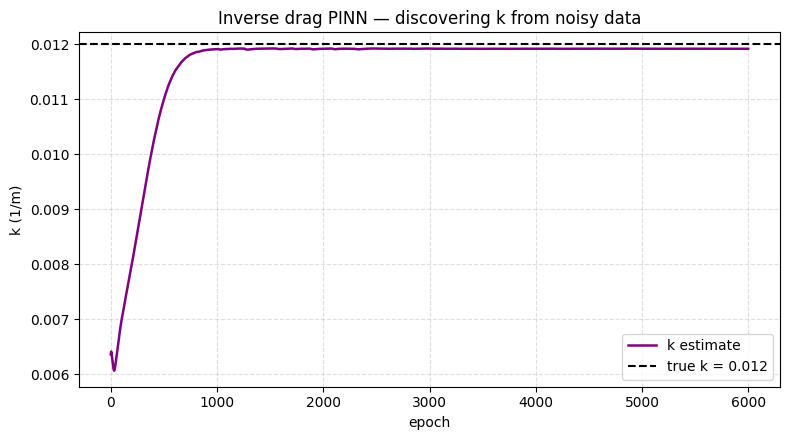

In [7]:
plt.figure(figsize=(8,4.5))
plt.plot(hist_k, color='purple', lw=1.8, label='k estimate')
plt.axhline(k_true, ls='--', color='k', label=f'true k = {k_true}')
plt.xlabel('epoch'); plt.ylabel('k (1/m)')
plt.title('Inverse drag PINN — discovering k from noisy data')
plt.legend(); plt.grid(True, ls='--', alpha=0.4); plt.tight_layout(); plt.show()

## The recovered trajectory vs data vs RK4 truth
Final check: I draw the network's learned trajectory through the noisy points and overlay the
true RK4 trajectory. If the learned curve sits on the truth *and* I recovered the right $k$,
then the PINN genuinely discovered the physics rather than just bending through the noise.

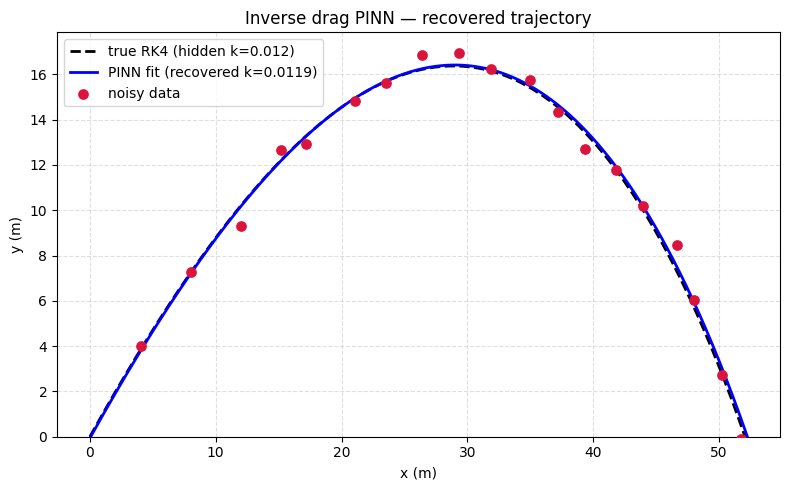

In [8]:
net.eval()
with torch.no_grad():
    tt = torch.tensor(T, dtype=torch.float32, device=device).unsqueeze(1)
    o  = net(tt)
    xp = o[:, 0].cpu().numpy()*x_scale; yp = o[:, 1].cpu().numpy()*y_scale
plt.figure(figsize=(8,5))
plt.plot(X, Y, 'k--', lw=2, label=f'true RK4 (hidden k={k_true})')
plt.plot(xp, yp, 'b-', lw=2, label=f'PINN fit (recovered k={k_est:.4f})')
plt.scatter(x_obs, y_obs, color='crimson', s=45, zorder=5, label='noisy data')
plt.xlabel('x (m)'); plt.ylabel('y (m)'); plt.title('Inverse drag PINN — recovered trajectory')
plt.legend(); plt.grid(True, ls='--', alpha=0.4); plt.ylim(bottom=0)
plt.tight_layout(); plt.show()

## What I take away from Notebook 5 (and the whole project)
- I discovered a hidden coefficient of a **nonlinear ODE** — the drag $k$ — from only 20 noisy
  points, by making $k$ a trainable parameter (kept $\ge 0$ with `softplus`) optimised jointly
  with a data-fitting, physics-obeying network. This is the inverse problem PINNs are famous for.
- The same three ingredients recur in every notebook: **autograd derivatives**, a **`Tanh`**
  network with **normalised** inputs and outputs, and a **weighted, scale-normalised loss**.
- Across the five notebooks I went from (1) one fixed parabola, to (2) a whole family of
  parabolas, to (3) realistic drag with an RK4 ground truth, and then **reversed the arrow**:
  (4) recovering launch conditions and (5) discovering a drag coefficient — i.e. from *physics
  to data* and back from *data to physics*. That round trip is, to me, the real lesson of the
  project: a PINN can serve equally as a forward simulator and as an instrument for measuring
  the world.

**Ideas to extend this:** discover $k$ **and** the launch velocity at once; test how recovery
degrades as I add more noise or fewer points; or put a believable error bar on the recovered
$k$ by repeating the fit over many noisy datasets.